# Figure 5 generator: removed-part-aware vs largest-hole-only failure cases

This notebook generates:
- 8 panel images (2 samples x 4 columns)
- 1 final Figure 5 composite image

Layout per row:
1. Damaged mesh with **all boundary loops**
2. **Removed-part-aware** target selection
3. **Largest-hole-only** target selection
4. Failure result / repaired mesh from largest-hole-only (if a repaired mesh or png is found)

The notebook is self-contained and includes fallback implementations for:
- boundary edge extraction
- boundary loops
- largest-hole selection
- removed-part bbox loading
- simple removed-part-aware selection heuristic

You only need to edit the **CONFIG** cell.

In [5]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.image as mpimg
import open3d as o3d

PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / 'dataset'
VIS_DIR = PROJECT_ROOT / 'results' / 'vis'
PANEL_DIR = VIS_DIR / 'figure5_panels'
PANEL_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)
partnetPath = Path("E:/datasets/partnet/data_v0/data_v0")
print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATASET_DIR   =', DATASET_DIR)
print('VIS_DIR       =', VIS_DIR)
print('PANEL_DIR     =', PANEL_DIR)

PROJECT_ROOT = D:\MyJupyter\Works\3Dsegment
DATASET_DIR   = D:\MyJupyter\Works\3Dsegment\dataset
VIS_DIR       = D:\MyJupyter\Works\3Dsegment\results\vis
PANEL_DIR     = D:\MyJupyter\Works\3Dsegment\results\vis\figure5_panels


In [6]:
# =========================
# CONFIG
# =========================
# You can change these two sample ids.
# Their dataset folders should exist at: dataset/<sample_id>/

SAMPLE_IDS = ['35580', '42103']

# Camera shared across the first 3 columns.
# Adjust these if the opening is not clearly visible.
VIEW_ELEV = 18
VIEW_AZIM = -58

# For the 4th column, the notebook tries to find a repaired mesh/image automatically.
# You can force a path here if needed (otherwise leave as None).
OVERRIDE_REPAIR_RESULT = {
    '35580': None,
    '42103': None,
}

# Output names
OUT_FIG_PNG = VIS_DIR / 'figure5_target_selection_failure_cases.png'
OUT_FIG_PDF = VIS_DIR / 'figure5_target_selection_failure_cases.pdf'

print('Samples =', SAMPLE_IDS)

Samples = ['35580', '42103']


In [10]:
def read_mesh(mesh_path):
    mesh = o3d.io.read_triangle_mesh(str(mesh_path))
    if mesh.is_empty():
        raise FileNotFoundError(f'Cannot read mesh: {mesh_path}')
    mesh.compute_vertex_normals()
    V = np.asarray(mesh.vertices)
    F = np.asarray(mesh.triangles)
    return V, F, mesh


def merge_meshes(mesh_list):
    out = o3d.geometry.TriangleMesh()
    v_offset = 0
    all_v = []
    all_f = []
    for mesh in mesh_list:
        V = np.asarray(mesh.vertices)
        F = np.asarray(mesh.triangles)
        if len(V) == 0 or len(F) == 0:
            continue
        all_v.append(V)
        all_f.append(F + v_offset)
        v_offset += len(V)
    if not all_v:
        return None
    V = np.vstack(all_v)
    F = np.vstack(all_f)
    out.vertices = o3d.utility.Vector3dVector(V)
    out.triangles = o3d.utility.Vector3iVector(F)
    out.compute_vertex_normals()
    return out


def boundary_edges_from_faces(F):
    edge_count = {}
    for tri in F:
        tri = list(map(int, tri))
        edges = [(tri[0], tri[1]), (tri[1], tri[2]), (tri[2], tri[0])]
        for a, b in edges:
            e = tuple(sorted((a, b)))
            edge_count[e] = edge_count.get(e, 0) + 1
    boundary = [e for e, c in edge_count.items() if c == 1]
    return boundary


def boundary_edges_to_loops(boundary_edges):
    from collections import defaultdict
    adj = defaultdict(list)
    for a, b in boundary_edges:
        adj[a].append(b)
        adj[b].append(a)

    visited_edges = set()
    loops = []

    def ekey(u, v):
        return tuple(sorted((int(u), int(v))))

    for a, b in boundary_edges:
        if ekey(a, b) in visited_edges:
            continue
        loop = [a, b]
        visited_edges.add(ekey(a, b))
        prev, cur = a, b

        while True:
            nbrs = adj[cur]
            nxt_candidates = [n for n in nbrs if n != prev and ekey(cur, n) not in visited_edges]
            if not nxt_candidates:
                break
            nxt = nxt_candidates[0]
            loop.append(nxt)
            visited_edges.add(ekey(cur, nxt))
            prev, cur = cur, nxt
            if cur == loop[0]:
                break

        if len(loop) >= 3:
            if loop[-1] == loop[0]:
                loop = loop[:-1]
            loops.append(loop)
    return loops


def loop_perimeter(V, loop):
    pts = V[np.array(loop, dtype=int)]
    pts2 = np.vstack([pts, pts[0]])
    return float(np.linalg.norm(pts2[1:] - pts2[:-1], axis=1).sum())


def bbox_from_points(P):
    pmin = P.min(axis=0)
    pmax = P.max(axis=0)
    return pmin, pmax


def expand_bbox(pmin, pmax, margin_ratio=0.08):
    diag = np.linalg.norm(pmax - pmin)
    m = margin_ratio * diag
    return pmin - m, pmax + m


def point_bbox_distance(p, pmin, pmax):
    q = np.maximum(pmin, np.minimum(p, pmax))
    return float(np.linalg.norm(p - q))


def select_removed_part_aware_loops(V, loops, bbox_min, bbox_max, margin_ratio=0.08):
    # Simple heuristic: select loops whose centroid / vertices are closest to the removed-part bbox.
    ebmin, ebmax = expand_bbox(bbox_min, bbox_max, margin_ratio=margin_ratio)
    scores = []
    for i, loop in enumerate(loops):
        pts = V[np.array(loop, dtype=int)]
        centroid = pts.mean(axis=0)
        d_cent = point_bbox_distance(centroid, ebmin, ebmax)
        d_min = min(point_bbox_distance(p, ebmin, ebmax) for p in pts)
        score = min(d_cent, d_min)
        scores.append((i, score))
    scores = sorted(scores, key=lambda x: x[1])
    if not scores:
        return []
    best = scores[0][1]
    keep = [i for i, s in scores if s <= max(best * 1.5, 1e-6)]
    return keep


def select_largest_hole(V, loops):
    if not loops:
        return None
    perims = [loop_perimeter(V, loop) for loop in loops]
    return int(np.argmax(perims))


def load_removed_part_bbox(sample_dir, V=None, loops=None):
    meta_path = sample_dir / 'meta.json'
    meta = json.loads(meta_path.read_text(encoding='utf-8'))

    removed_objs = meta['removed_obj_files']
    meshes = []

    # 优先尝试 meta.json 里的原始 source_dir
    source_dir = Path(meta['source_dir'])

    candidate_roots = []
    if source_dir.exists():
        candidate_roots.append(source_dir)

    # 再尝试你当前机器上的 PartNet 根目录
    # 这里默认 sample_id 对应 PartNet 的样本目录名
    sample_id = str(meta.get('sample_id', sample_dir.name))
    candidate_roots.append(partnetPath / sample_id)

    # 去重
    uniq_roots = []
    seen = set()
    for r in candidate_roots:
        rr = str(r)
        if rr not in seen:
            uniq_roots.append(r)
            seen.add(rr)

    found_paths = []
    for rel in removed_objs:
        hit = None
        for root in uniq_roots:
            p = root / rel
            if p.exists():
                hit = p
                break
        if hit is not None:
            found_paths.append(hit)

    for p in found_paths:
        m = o3d.io.read_triangle_mesh(str(p))
        if not m.is_empty():
            meshes.append(m)

    merged = merge_meshes(meshes)

    if merged is not None:
        P = np.asarray(merged.vertices)
        bmin, bmax = bbox_from_points(P)
        return bmin, bmax

    # fallback：如果还是找不到，就退化成 boundary loop 粗估计
    if V is not None and loops is not None and len(loops) > 0:
        perims = [loop_perimeter(V, loop) for loop in loops]
        idx = int(np.argmax(perims))
        pts = V[np.array(loops[idx], dtype=int)]
        bmin, bmax = bbox_from_points(pts)
        diag = np.linalg.norm(bmax - bmin)
        margin = 0.08 * diag
        return bmin - margin, bmax + margin

    raise FileNotFoundError(f'Failed to load removed part meshes for {sample_dir.name}')


def setup_3d_axes(ax, V, elev=18, azim=-58):
    pmin, pmax = V.min(axis=0), V.max(axis=0)
    center = (pmin + pmax) / 2
    size = (pmax - pmin).max() * 0.58
    ax.set_xlim(center[0] - size, center[0] + size)
    ax.set_ylim(center[1] - size, center[1] + size)
    ax.set_zlim(center[2] - size, center[2] + size)
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
    try:
        ax.set_box_aspect([1, 1, 1])
    except Exception:
        pass


def render_mesh_panel(mesh_path, out_path, all_loops=None, selected_loops=None, bbox=None,
                      title=None, view_elev=18, view_azim=-58,
                      mesh_color='#d9d9d9', loop_color_all='#2ca02c',
                      loop_color_sel='#d62728', bbox_color='#f39c12'):
    V, F, mesh = read_mesh(mesh_path)

    # ---------- face normals ----------
    tris = V[F]   # (n_faces, 3, 3)
    e1 = tris[:, 1] - tris[:, 0]
    e2 = tris[:, 2] - tris[:, 0]
    face_normals = np.cross(e1, e2)

    norm = np.linalg.norm(face_normals, axis=1, keepdims=True)
    norm[norm < 1e-12] = 1.0
    face_normals = face_normals / norm

    # ---------- simple directional lighting ----------
    # 光线从“左前上方”打过来，适合看椅子结构
    light_dir = np.array([0.35, -0.45, 0.82], dtype=float)
    light_dir = light_dir / np.linalg.norm(light_dir)

    intensity = face_normals @ light_dir
    intensity = np.clip(intensity, 0, 1)

    # ambient + diffuse
    ambient = 0.45
    diffuse = 0.55
    shading = ambient + diffuse * intensity
    shading = np.clip(shading, 0, 1)

    # ---------- base color -> shaded facecolors ----------
    import matplotlib.colors as mcolors
    base_rgb = np.array(mcolors.to_rgb(mesh_color))
    facecolors = np.clip(base_rgb[None, :] * shading[:, None], 0, 1)

    fig = plt.figure(figsize=(4.0, 4.0))
    ax = fig.add_subplot(111, projection='3d')

    poly = Poly3DCollection(
        tris,
        facecolors=facecolors,
        edgecolor=(0.55, 0.55, 0.55, 0.35),   # 很淡的边线，增强层次
        linewidths=0.15,
        alpha=1.0
    )
    ax.add_collection3d(poly)

    # ---------- boundary loops ----------
    if all_loops is not None:
        for loop in all_loops:
            pts = V[np.array(loop, dtype=int)]
            pts = np.vstack([pts, pts[0]])
            ax.plot(
                pts[:, 0], pts[:, 1], pts[:, 2],
                color=loop_color_all, linewidth=2.0, alpha=0.95
            )

    if selected_loops is not None:
        for loop in selected_loops:
            pts = V[np.array(loop, dtype=int)]
            pts = np.vstack([pts, pts[0]])
            ax.plot(
                pts[:, 0], pts[:, 1], pts[:, 2],
                color=loop_color_sel, linewidth=3.0, alpha=1.0
            )

    # ---------- bbox ----------
    if bbox is not None:
        draw_bbox(ax, bbox[0], bbox[1], color=bbox_color, lw=1.8)

    # ---------- view ----------
    setup_3d_axes(ax, V, elev=view_elev, azim=view_azim)

    # 白底 + 去网格
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    ax.grid(False)

    if title:
        ax.set_title(title, fontsize=11, pad=8)

    plt.tight_layout()
    fig.savefig(out_path, dpi=260, bbox_inches='tight', pad_inches=0.02)
    plt.close(fig)
    return out_path


def render_text_placeholder(out_path, text, figsize=(4.0, 4.0)):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)
    ax.set_axis_off()
    ax.text(0.5, 0.5, text, ha='center', va='center', fontsize=12)
    fig.savefig(out_path, dpi=220, bbox_inches='tight', pad_inches=0.02)
    plt.close(fig)
    return out_path


def find_repair_result(sample_id, sample_dir):
    override = OVERRIDE_REPAIR_RESULT.get(sample_id)
    if override is not None:
        override = Path(override)
        if override.exists():
            return override

    candidates = [
        sample_dir / 'M_r_planar_largest_hole_only.obj',
        sample_dir / 'M_r_planar_largest_hole.obj',
        sample_dir / 'M_r_largest_hole_only.obj',
        sample_dir / 'planar_largest_hole_only.obj',
        sample_dir / 'largest_hole_only.obj',
        VIS_DIR / f'{sample_id}_planar_largest_hole_only.png',
        VIS_DIR / f'{sample_id}_largest_hole_only.png',
        VIS_DIR / sample_id / 'planar_largest_hole_only.png',
        VIS_DIR / sample_id / 'largest_hole_only.png',
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

In [11]:
generated = []

for sample_id in SAMPLE_IDS:
    sample_dir = DATASET_DIR / sample_id
    md_path = sample_dir / 'M_d.obj'
    assert md_path.exists(), f'Missing sample mesh: {md_path}'

    V, F, _ = read_mesh(md_path)
    boundary_edges = boundary_edges_from_faces(F)
    loops = boundary_edges_to_loops(boundary_edges)
    print(f'[{sample_id}] #boundary loops =', len(loops))

    bmin, bmax = load_removed_part_bbox(sample_dir, V=V, loops=loops)
    rp_idx = select_removed_part_aware_loops(V, loops, bmin, bmax)
    lh_idx = select_largest_hole(V, loops)

    rp_loops = [loops[i] for i in rp_idx] if rp_idx else []
    lh_loops = [loops[lh_idx]] if lh_idx is not None else []

    p1 = PANEL_DIR / f'{sample_id}_all_loops_marked.png'
    p2 = PANEL_DIR / f'{sample_id}_rp_aware_selected.png'
    p3 = PANEL_DIR / f'{sample_id}_largest_hole_selected.png'
    p4 = PANEL_DIR / f'{sample_id}_repair_result.png'

    render_mesh_panel(
        md_path, p1,
        all_loops=loops,
        selected_loops=None,
        bbox=None,
        title=None,
        view_elev=VIEW_ELEV,
        view_azim=VIEW_AZIM,
        loop_color_all='#2ca02c'
    )

    render_mesh_panel(
        md_path, p2,
        all_loops=loops,
        selected_loops=rp_loops,
        bbox=(bmin, bmax),
        title=None,
        view_elev=VIEW_ELEV,
        view_azim=VIEW_AZIM,
        loop_color_all='#c7c7c7',
        loop_color_sel='#d62728',
        bbox_color='#f39c12'
    )

    render_mesh_panel(
        md_path, p3,
        all_loops=loops,
        selected_loops=lh_loops,
        bbox=None,
        title=None,
        view_elev=VIEW_ELEV,
        view_azim=VIEW_AZIM,
        loop_color_all='#c7c7c7',
        loop_color_sel='#1f77b4'
    )

    repair_src = find_repair_result(sample_id, sample_dir)
    if repair_src is None:
        render_text_placeholder(p4, f'{sample_id}\nrepair result not found\n(set OVERRIDE_REPAIR_RESULT)', figsize=(4.0, 4.0))
    else:
        repair_src = Path(repair_src)
        if repair_src.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
            img = mpimg.imread(repair_src)
            fig = plt.figure(figsize=(4.0, 4.0))
            ax = fig.add_subplot(111)
            ax.imshow(img)
            ax.set_axis_off()
            plt.tight_layout()
            fig.savefig(p4, dpi=220, bbox_inches='tight', pad_inches=0.02)
            plt.close(fig)
        else:
            render_mesh_panel(
                repair_src, p4,
                all_loops=None,
                selected_loops=None,
                bbox=None,
                title=None,
                view_elev=VIEW_ELEV,
                view_azim=VIEW_AZIM
            )

    generated.append({
        'sample_id': sample_id,
        'all_loops': p1,
        'rp_aware': p2,
        'largest_hole': p3,
        'repair_result': p4,
    })

generated

[35580] #boundary loops = 50
[42103] #boundary loops = 61


[{'sample_id': '35580',
  'all_loops': WindowsPath('D:/MyJupyter/Works/3Dsegment/results/vis/figure5_panels/35580_all_loops_marked.png'),
  'rp_aware': WindowsPath('D:/MyJupyter/Works/3Dsegment/results/vis/figure5_panels/35580_rp_aware_selected.png'),
  'largest_hole': WindowsPath('D:/MyJupyter/Works/3Dsegment/results/vis/figure5_panels/35580_largest_hole_selected.png'),
  'repair_result': WindowsPath('D:/MyJupyter/Works/3Dsegment/results/vis/figure5_panels/35580_repair_result.png')},
 {'sample_id': '42103',
  'all_loops': WindowsPath('D:/MyJupyter/Works/3Dsegment/results/vis/figure5_panels/42103_all_loops_marked.png'),
  'rp_aware': WindowsPath('D:/MyJupyter/Works/3Dsegment/results/vis/figure5_panels/42103_rp_aware_selected.png'),
  'largest_hole': WindowsPath('D:/MyJupyter/Works/3Dsegment/results/vis/figure5_panels/42103_largest_hole_selected.png'),
  'repair_result': WindowsPath('D:/MyJupyter/Works/3Dsegment/results/vis/figure5_panels/42103_repair_result.png')}]

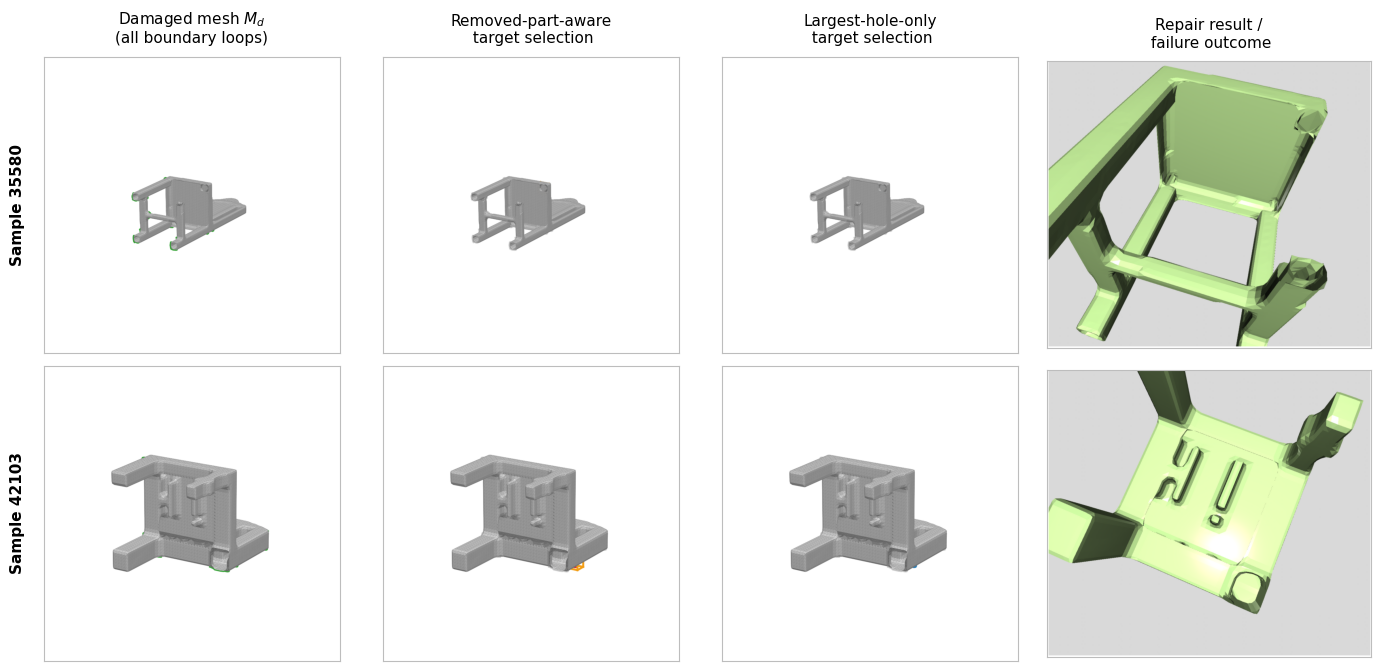

Saved: D:\MyJupyter\Works\3Dsegment\results\vis\figure5_target_selection_failure_cases.png


In [12]:
COL_TITLES = [
    'Damaged mesh $M_d$\n(all boundary loops)',
    'Removed-part-aware\n target selection',
    'Largest-hole-only\n target selection',
    'Repair result /\n failure outcome',
]

fig, axes = plt.subplots(len(generated), 4, figsize=(14, 6.8))
if len(generated) == 1:
    axes = axes[None, :]

for i, row in enumerate(generated):
    row_imgs = [row['all_loops'], row['rp_aware'], row['largest_hole'], row['repair_result']]
    for j, p in enumerate(row_imgs):
        ax = axes[i, j]
        img = mpimg.imread(p)
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)
            spine.set_edgecolor('#bdbdbd')
        if i == 0:
            ax.set_title(COL_TITLES[j], fontsize=11, pad=10)
        if j == 0:
            ax.text(-0.09, 0.5, f"Sample {row['sample_id']}", transform=ax.transAxes,
                    rotation=90, va='center', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
fig.savefig(OUT_FIG_PNG, dpi=300, bbox_inches='tight')
#fig.savefig(OUT_FIG_PDF, bbox_inches='tight')
plt.show()
print('Saved:', OUT_FIG_PNG)
#print('Saved:', OUT_FIG_PDF)

Suggested caption:

> **Figure 5. Failure cases of naive largest-hole-only target selection.** For damaged meshes with multiple boundary loops, the largest boundary loop is not necessarily the one induced by semantic part removal. The removed-part-aware strategy uses the bounding box of the removed part to localize the correct target loop near the removal region, whereas the naive largest-hole-only strategy may select an unrelated boundary loop elsewhere on the mesh. As a result, the largest-hole-only baseline often repairs the wrong region and leaves the true removal-induced opening unresolved.